# Exploratory Data Analysis

## Movie Sentiment Analysis

Data Set link : https://ai.stanford.edu/~amaas/data/sentiment/

Kaggle Dataset Link : https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
url_path = "data/IMDB Dataset.csv"
df_original =pd.read_csv(url_path)
df_original.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df = df_original.copy(deep=True)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Basic Info

In [5]:
df.columns

Index(['review', 'sentiment'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [7]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [8]:
50000-49582 # no of duplicate rows

418

In [10]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

## Descriptive Stats

In [11]:
# summary Statistics

df["review_char_len"] = df["review"].apply(len)
df["review_word_len"] = df['review'].apply(lambda x: len(x.split()))

# Description

print(df[['review_char_len', "review_word_len"]].describe())

       review_char_len  review_word_len
count     50000.000000     50000.000000
mean       1309.431020       231.156940
std         989.728014       171.343997
min          32.000000         4.000000
25%         699.000000       126.000000
50%         970.000000       173.000000
75%        1590.250000       280.000000
max       13704.000000      2470.000000


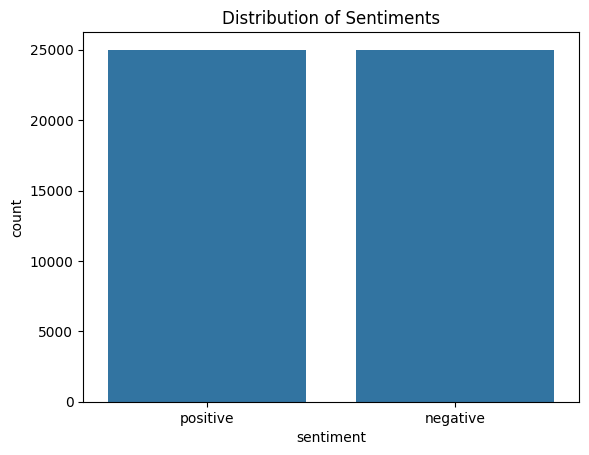

In [22]:
# histogram of sentiment

# Sentiment distribution
sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Sentiments")
plt.show()

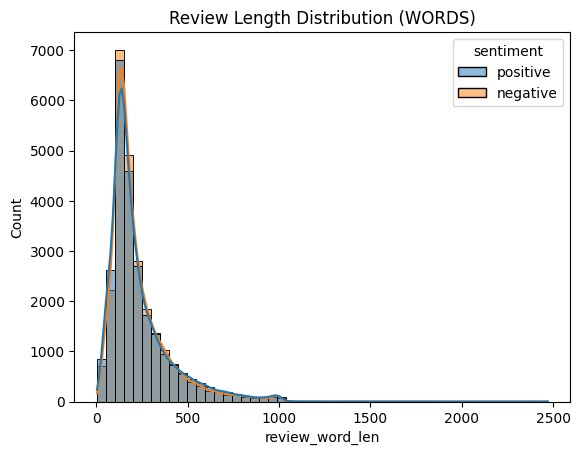

In [13]:
## histogram of the review word length
sns.histplot(data=df, x='review_word_len', bins=50, hue='sentiment', kde=True)
plt.title("Review Length Distribution (WORDS)")
plt.show()

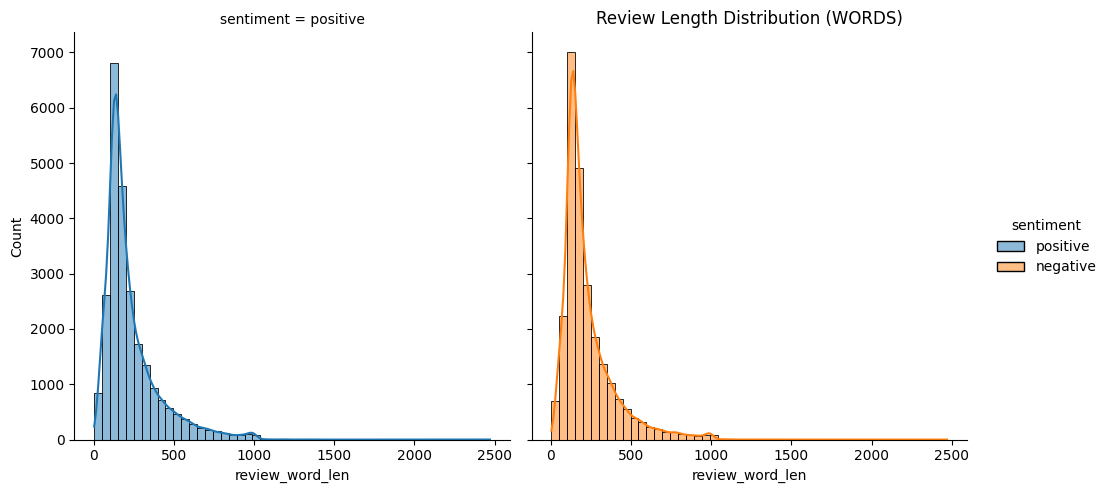

In [15]:
## distribution of the review word length
sns.displot(data=df, x='review_word_len',col='sentiment', bins=50, hue='sentiment', kde=True, )
plt.title("Review Length Distribution (WORDS)")
plt.show()

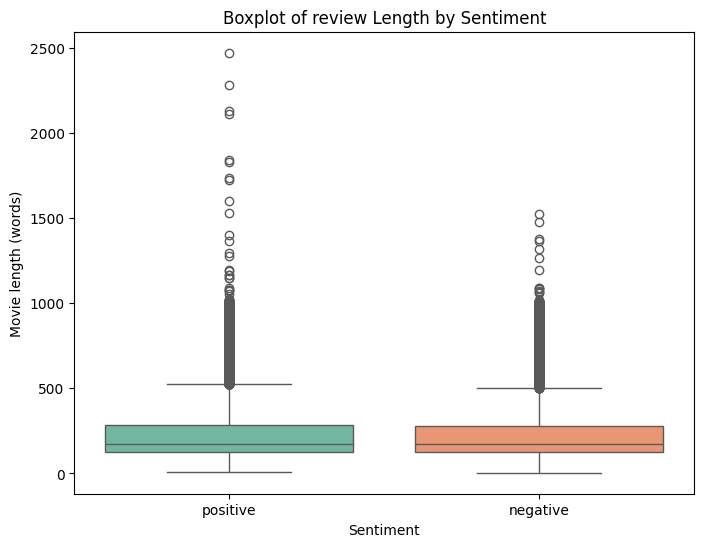

In [17]:
## Box plot of review length by sentiment

plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data = df, palette="Set2", hue= "sentiment")
plt.title("Boxplot of review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Movie length (words)")
plt.show()

## Removing Outliers with IQR


In [ ]:
Q1 = df["review_word_len"].quantile(0.25)
Q3 = df["review_word_len"].quantile(0.75)
IQR = Q3-Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = df[(df["review_word_len"] < lower_fence) | (df["review_word_len"] > upper_fence)]
outliers

,review,sentiment,review_char_len,review_word_len
26,"""The Cell"" is an exotic masterpiece, a dizzyin...",positive,3149,570
29,'War movie' is a Hollywood genre that has been...,positive,3791,615
33,One of the most significant quotes from the en...,positive,4009,652
48,Preston Sturgis' THE POWER AND THE GLORY was u...,positive,3975,707
51,"***SPOILERS*** All too, in real life as well a...",positive,3371,621
...,...,...,...,...
49946,One of the greatest lessons I ever had in how ...,negative,2901,535
49948,"It is the early morning of our discontent, and...",negative,5847,986
49954,Why is it that every time I mention this movie...,negative,2789,532
49959,"My thoughts on the movie, 9<br /><br />It was ...",negative,3560,625


In [23]:
print("Number of outliers:", outliers.shape[0])

Number of outliers: 3708


In [21]:
outliers.describe()

,review_char_len,review_word_len
count,3708.000000,3708.000000
mean,4002.184736,698.197950
std,965.907822,164.958103
min,2599.000000,512.000000
25%,3267.750000,569.000000
50%,3749.500000,655.000000
75%,4559.250000,793.000000
max,13704.000000,2470.000000


In [25]:
# FE STEP
df_clean_from_iqr = df[(df['review_word_len'] >= lower_fence) & (df['review_word_len'] <= upper_fence)]
print("Orignal Data :", df.shape[0])
print("Cleaned Data :", df_clean_from_iqr.shape[0])

Orignal Data : 50000
Cleaned Data : 46292


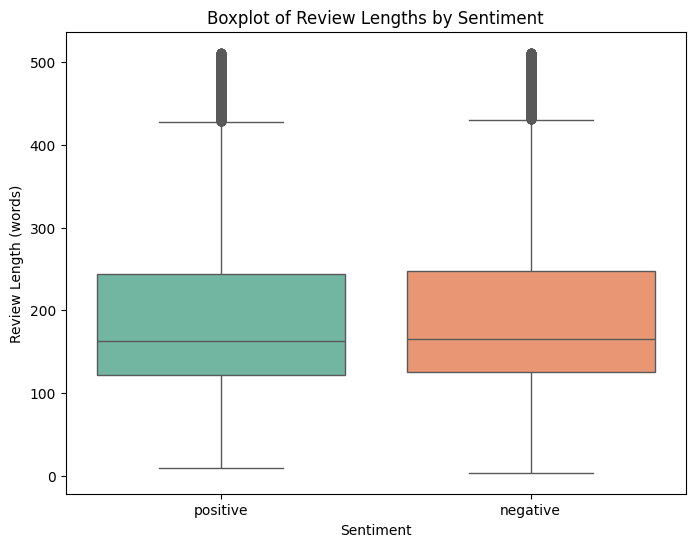

In [26]:
# Boxplot of Review Length by Sentiment
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df_clean_from_iqr, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

In [27]:
df_clean_from_iqr.head()

,review,sentiment,review_char_len,review_word_len
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


In [ ]:
# how many positive words in a positive case -->
# how many negative words in a negative case -->